# Dataset 1: Klasifikasi Penyakit Kardiovaskular

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Library berhasil diimport.")

Library berhasil diimport.


---
## 2. Load Data & Inspeksi Awal

In [2]:
df = pd.read_csv('../../dataset/cardio_train.csv', sep=';')

print("Shape:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nSample data:")
df.head()

Shape: (70000, 13)

Tipe data:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Sample data:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
print("Missing values per kolom:")
print(df.isnull().sum())

print("\nStatistik deskriptif:")
df.describe()

Missing values per kolom:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Statistik deskriptif:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


---
## 3. Feature Engineering & Data Cleaning

Langkah yang dilakukan:
- Konversi `age` dari hari ke tahun agar lebih interpretatif
- Hapus kolom `id` karena tidak mengandung informasi prediktif
- Filter outlier tekanan darah berdasarkan batas klinis:
  - `ap_hi` (sistolik): 60–250 mmHg
  - `ap_lo` (diastolik): 40–200 mmHg
  - Syarat fisiologis: `ap_lo < ap_hi`

In [4]:
df['age'] = (df['age'] / 365).round(1)

df.drop(columns=['id'], inplace=True)

n_before = df.shape[0]
df = df[
    (df['ap_hi'] >= 60) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 200) &
    (df['ap_lo'] < df['ap_hi'])
].copy()
n_after = df.shape[0]

print(f"Shape sebelum cleaning : ({n_before}, {df.shape[1]})")
print(f"Shape setelah cleaning  : {df.shape}")
print(f"Baris dihapus           : {n_before - n_after}")
print("\nStatistik ap_hi dan ap_lo setelah cleaning:")
print(df[['ap_hi', 'ap_lo']].describe())

Shape sebelum cleaning : (70000, 12)
Shape setelah cleaning  : (68672, 12)
Baris dihapus           : 1328

Statistik ap_hi dan ap_lo setelah cleaning:
              ap_hi         ap_lo
count  68672.000000  68672.000000
mean     126.674132     81.307374
std       16.694859      9.454808
min       60.000000     40.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    182.000000


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Semua Fitur

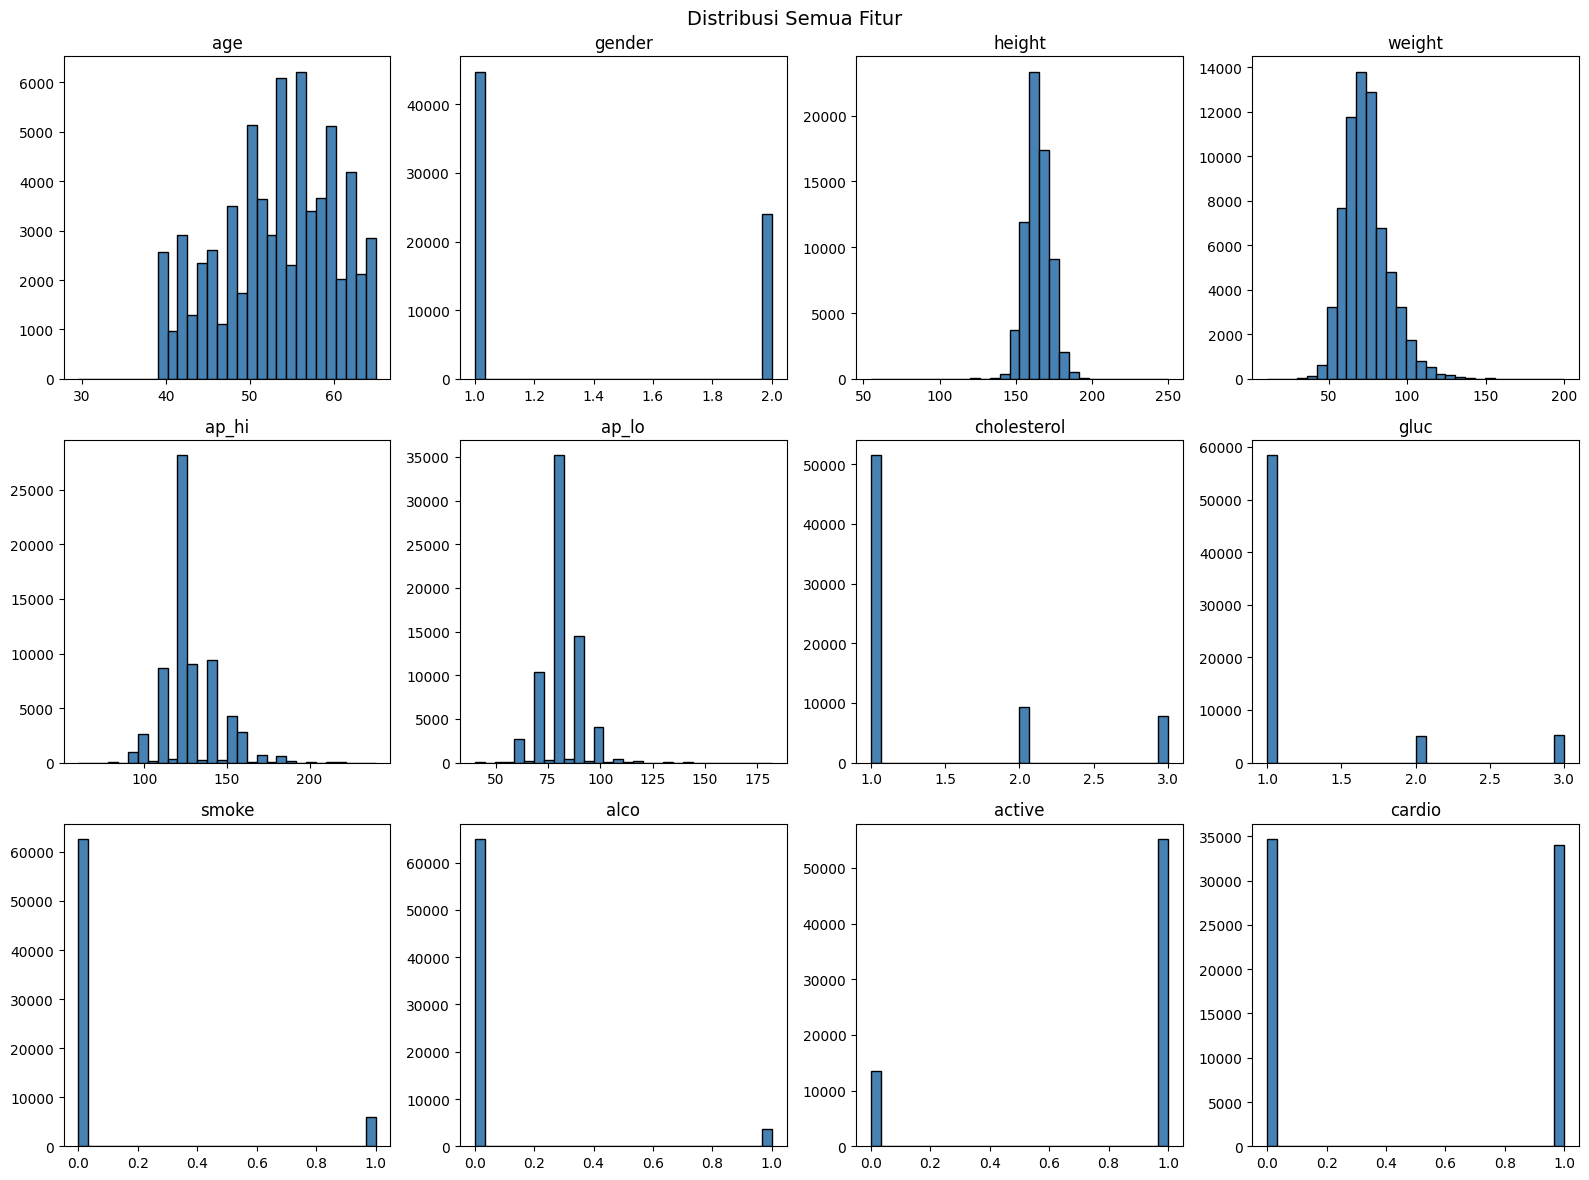

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('dist_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Distribusi Target (cardio)

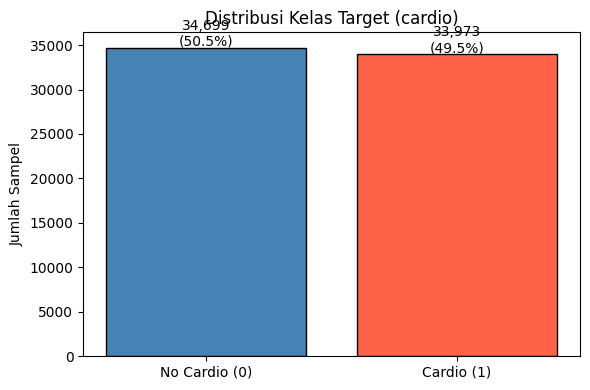

Distribusi kelas:
cardio
0    34699
1    33973
Name: count, dtype: int64


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['cardio'].value_counts()
ax.bar(['No Cardio (0)', 'Cardio (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Distribusi Kelas Target (cardio)')
ax.set_ylabel('Jumlah Sampel')

for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('cardio_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distribusi kelas:")
print(counts)

### 4.3 Heatmap Korelasi Antar Fitur

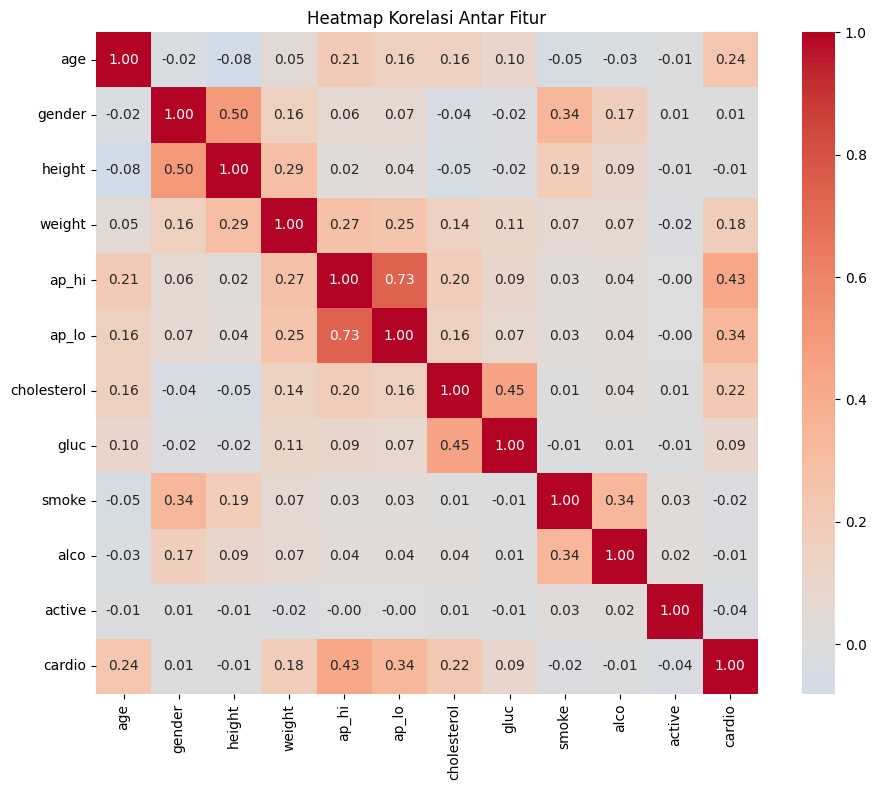

Korelasi fitur terhadap target (cardio):
cardio         1.000
ap_hi          0.428
ap_lo          0.340
age            0.239
cholesterol    0.221
weight         0.180
gluc           0.090
gender         0.007
alco          -0.009
height        -0.011
smoke         -0.016
active        -0.037
Name: cardio, dtype: float64


In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Korelasi fitur terhadap target (cardio):")
print(corr_matrix['cardio'].sort_values(ascending=False).round(3))

---
## 5. Preprocessing

### 5.1 Standardisasi (StandardScaler)

StandardScaler digunakan karena beberapa model (Logistic Regression, KNN, SVM) sensitif terhadap perbedaan skala antar fitur. Scaling dilakukan sebelum feature selection agar skor F-test tidak bias oleh perbedaan magnitude.

In [8]:
X = df.drop(columns=['cardio'])
y = df['cardio']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Shape X_scaled:", X_scaled.shape)
print("\nVerifikasi scaling (mean ~0, std ~1):")
print(X_scaled.describe().loc[['mean', 'std']].round(3))

Shape X_scaled: (68672, 11)

Verifikasi scaling (mean ~0, std ~1):
      age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
mean  0.0    -0.0    -0.0     0.0    0.0    0.0          0.0  -0.0   -0.0   
std   1.0     1.0     1.0     1.0    1.0    1.0          1.0   1.0    1.0   

      alco  active  
mean  -0.0    -0.0  
std    1.0     1.0  


### 5.2 Feature Selection (SelectKBest — f_classif)

`f_classif` menggunakan ANOVA F-test untuk mengukur seberapa informatif tiap fitur terhadap target klasifikasi. Fitur dengan p-value tinggi (tidak signifikan secara statistik) cenderung tidak berkontribusi dan dapat dihapus.

F-Score semua fitur:
        feature     f_score  p_value
0         ap_hi  15399.8440   0.0000
1         ap_lo   8984.4805   0.0000
2           age   4173.9571   0.0000
3   cholesterol   3540.6629   0.0000
4        weight   2293.4589   0.0000
5          gluc    555.7825   0.0000
6        active     96.1888   0.0000
7         smoke     18.2608   0.0000
8        height      7.9209   0.0049
9          alco      5.2759   0.0216
10       gender      3.4550   0.0631


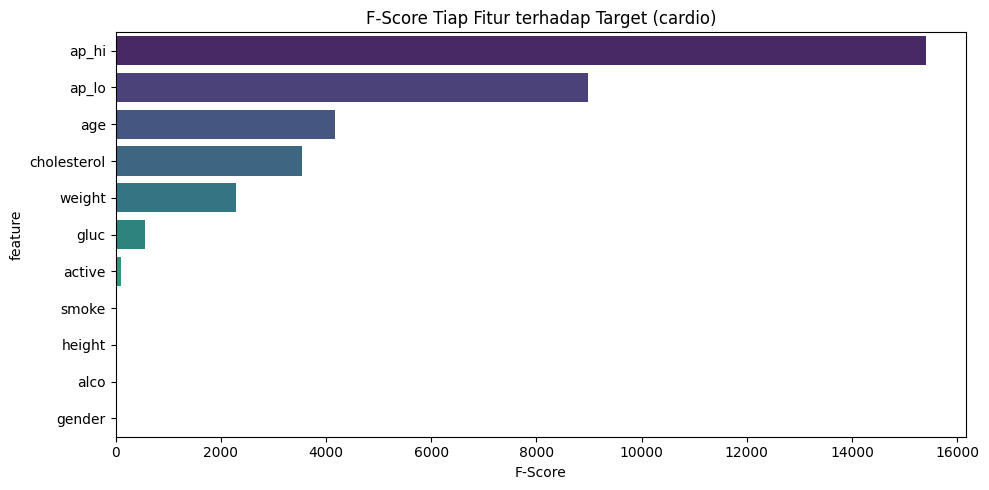

In [9]:
selector_all = SelectKBest(score_func=f_classif, k='all')
selector_all.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector_all.scores_,
    'p_value': selector_all.pvalues_
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("F-Score semua fitur:")
print(feature_scores.round(4).to_string())

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_scores, x='f_score', y='feature', palette='viridis')
plt.title('F-Score Tiap Fitur terhadap Target (cardio)')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('feature_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Pilih top-8 fitur berdasarkan F-score tertinggi.
# Fitur dengan p_value > 0.05 (tidak signifikan) dieksklusi secara implisit
# karena F-score mereka rendah dan tidak masuk top-8.
k_best     = 8
selector_k = SelectKBest(score_func=f_classif, k=k_best)
X_selected = pd.DataFrame(
    selector_k.fit_transform(X_scaled, y),
    columns=X.columns[selector_k.get_support()].tolist()
)

print(f"Fitur terpilih (top {k_best}):")
print(X_selected.columns.tolist())
print(f"\nShape setelah feature selection: {X_selected.shape}")

Fitur terpilih (top 8):
['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'active']

Shape setelah feature selection: (68672, 8)


---
## 6. Baseline Model

### 6.1 Definisi Model dan Fungsi Evaluasi

Model yang dievaluasi:
- **Logistic Regression** — model linear probabilistik, interpretabel
- **KNN** — berbasis jarak, non-parametrik
- **Decision Tree** — berbasis aturan, mudah diinterpretasi
- **Random Forest** — ensemble Decision Tree, robust terhadap overfitting
- **SVM** (LinearSVC + CalibratedClassifierCV) — margin-based classifier

Metrik evaluasi: Accuracy, Precision, Recall, F1-Score, CV Accuracy (k=5, StratifiedKFold)

In [11]:
splits = {'80:20': 0.2, '70:30': 0.3}


def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN'                : KNeighborsClassifier(),
        'Decision Tree'      : DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest'      : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'SVM'                : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE))
    }


def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv_folds=5):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    cv        = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)

    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred),    4),
        'F1-Score' : round(f1_score(y_te, y_pred),        4),
        'CV Mean'  : round(cv_scores.mean(),              4),
        'CV Std'   : round(cv_scores.std(),               4),
        'y_pred'   : y_pred
    }


print("Model dan fungsi evaluasi siap.")

Model dan fungsi evaluasi siap.


### 6.2 Baseline Sebelum Feature Selection

In [12]:
print("=" * 65)
print("BASELINE SEBELUM FEATURE SELECTION")
print("=" * 65)

results_before = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    split_results = []
    for name, model in get_models().items():
        print(f"  Training {name} | Split {split_name}...")
        result = evaluate_model(name, model, X_tr, X_te, y_tr, y_te)
        result.pop('y_pred')
        result['Split'] = split_name
        split_results.append(result)

    results_before[split_name] = pd.DataFrame(split_results)
    print(f"\n  Hasil Split {split_name} (Sebelum FS):")
    print(results_before[split_name].set_index('Model').drop(columns='Split').to_string())
    print()

BASELINE SEBELUM FEATURE SELECTION
  Training Logistic Regression | Split 80:20...
  Training KNN | Split 80:20...
  Training Decision Tree | Split 80:20...
  Training Random Forest | Split 80:20...
  Training SVM | Split 80:20...

  Hasil Split 80:20 (Sebelum FS):
                     Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Model                                                                      
Logistic Regression    0.7234     0.7524  0.6572    0.7016   0.7281  0.0036
KNN                    0.6925     0.6936  0.6779    0.6856   0.6946  0.0020
Decision Tree          0.6318     0.6282  0.6266    0.6274   0.6315  0.0018
Random Forest          0.7096     0.7117  0.6940    0.7028   0.7121  0.0025
SVM                    0.7233     0.7509  0.6593    0.7021   0.7280  0.0032

  Training Logistic Regression | Split 70:30...
  Training KNN | Split 70:30...
  Training Decision Tree | Split 70:30...
  Training Random Forest | Split 70:30...
  Training SVM | Split 70:30...

  Ha

### 6.3 Baseline Sesudah Feature Selection

In [13]:
print("=" * 65)
print("BASELINE SESUDAH FEATURE SELECTION")
print("=" * 65)

results_after = {}
predictions   = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    split_results = []
    split_preds   = {}

    for name, model in get_models().items():
        print(f"  Training {name} | Split {split_name}...")
        result = evaluate_model(name, model, X_tr, X_te, y_tr, y_te)
        split_preds[name] = {
            'y_te'  : y_te.values,
            'y_pred': result.pop('y_pred')
        }
        result['Split'] = split_name
        split_results.append(result)

    results_after[split_name] = pd.DataFrame(split_results)
    predictions[split_name]   = split_preds

    print(f"\n  Hasil Split {split_name} (Sesudah FS):")
    print(results_after[split_name].set_index('Model').drop(columns='Split').to_string())
    print()

BASELINE SESUDAH FEATURE SELECTION
  Training Logistic Regression | Split 80:20...
  Training KNN | Split 80:20...
  Training Decision Tree | Split 80:20...
  Training Random Forest | Split 80:20...
  Training SVM | Split 80:20...

  Hasil Split 80:20 (Sesudah FS):
                     Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Model                                                                      
Logistic Regression    0.7220     0.7511  0.6553    0.6999   0.7281  0.0035
KNN                    0.6965     0.6980  0.6811    0.6895   0.6962  0.0033
Decision Tree          0.6417     0.6464  0.6088    0.6271   0.6407  0.0013
Random Forest          0.6868     0.6857  0.6774    0.6815   0.6889  0.0032
SVM                    0.7220     0.7504  0.6562    0.7002   0.7276  0.0037

  Training Logistic Regression | Split 70:30...
  Training KNN | Split 70:30...
  Training Decision Tree | Split 70:30...
  Training Random Forest | Split 70:30...
  Training SVM | Split 70:30...

  Ha

### 6.4 Perbandingan Before vs After Feature Selection

In [14]:
print("=" * 75)
print("PERBANDINGAN BEFORE VS AFTER FEATURE SELECTION")
print("=" * 75)

for split_name in splits.keys():
    df_b = results_before[split_name].set_index('Model').drop(columns='Split')
    df_a = results_after[split_name].set_index('Model').drop(columns='Split')

    print(f"\nSplit {split_name}:")
    print(f"{'Model':<22} {'Stage':<8} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'CV':>7}")
    print("-" * 65)

    for model_name in df_b.index:
        b = df_b.loc[model_name]
        a = df_a.loc[model_name]
        print(f"{model_name:<22} {'Before':<8} {b['Accuracy']:>7.4f} {b['Precision']:>7.4f} {b['Recall']:>7.4f} {b['F1-Score']:>7.4f} {b['CV Mean']:>7.4f}")
        print(f"{'': <22} {'After':<8} {a['Accuracy']:>7.4f} {a['Precision']:>7.4f} {a['Recall']:>7.4f} {a['F1-Score']:>7.4f} {a['CV Mean']:>7.4f}")
        print()

PERBANDINGAN BEFORE VS AFTER FEATURE SELECTION

Split 80:20:
Model                  Stage        Acc    Prec     Rec      F1      CV
-----------------------------------------------------------------
Logistic Regression    Before    0.7234  0.7524  0.6572  0.7016  0.7281
                       After     0.7220  0.7511  0.6553  0.6999  0.7281

KNN                    Before    0.6925  0.6936  0.6779  0.6856  0.6946
                       After     0.6965  0.6980  0.6811  0.6895  0.6962

Decision Tree          Before    0.6318  0.6282  0.6266  0.6274  0.6315
                       After     0.6417  0.6464  0.6088  0.6271  0.6407

Random Forest          Before    0.7096  0.7117  0.6940  0.7028  0.7121
                       After     0.6868  0.6857  0.6774  0.6815  0.6889

SVM                    Before    0.7233  0.7509  0.6593  0.7021  0.7280
                       After     0.7220  0.7504  0.6562  0.7002  0.7276


Split 70:30:
Model                  Stage        Acc    Prec     Rec      F

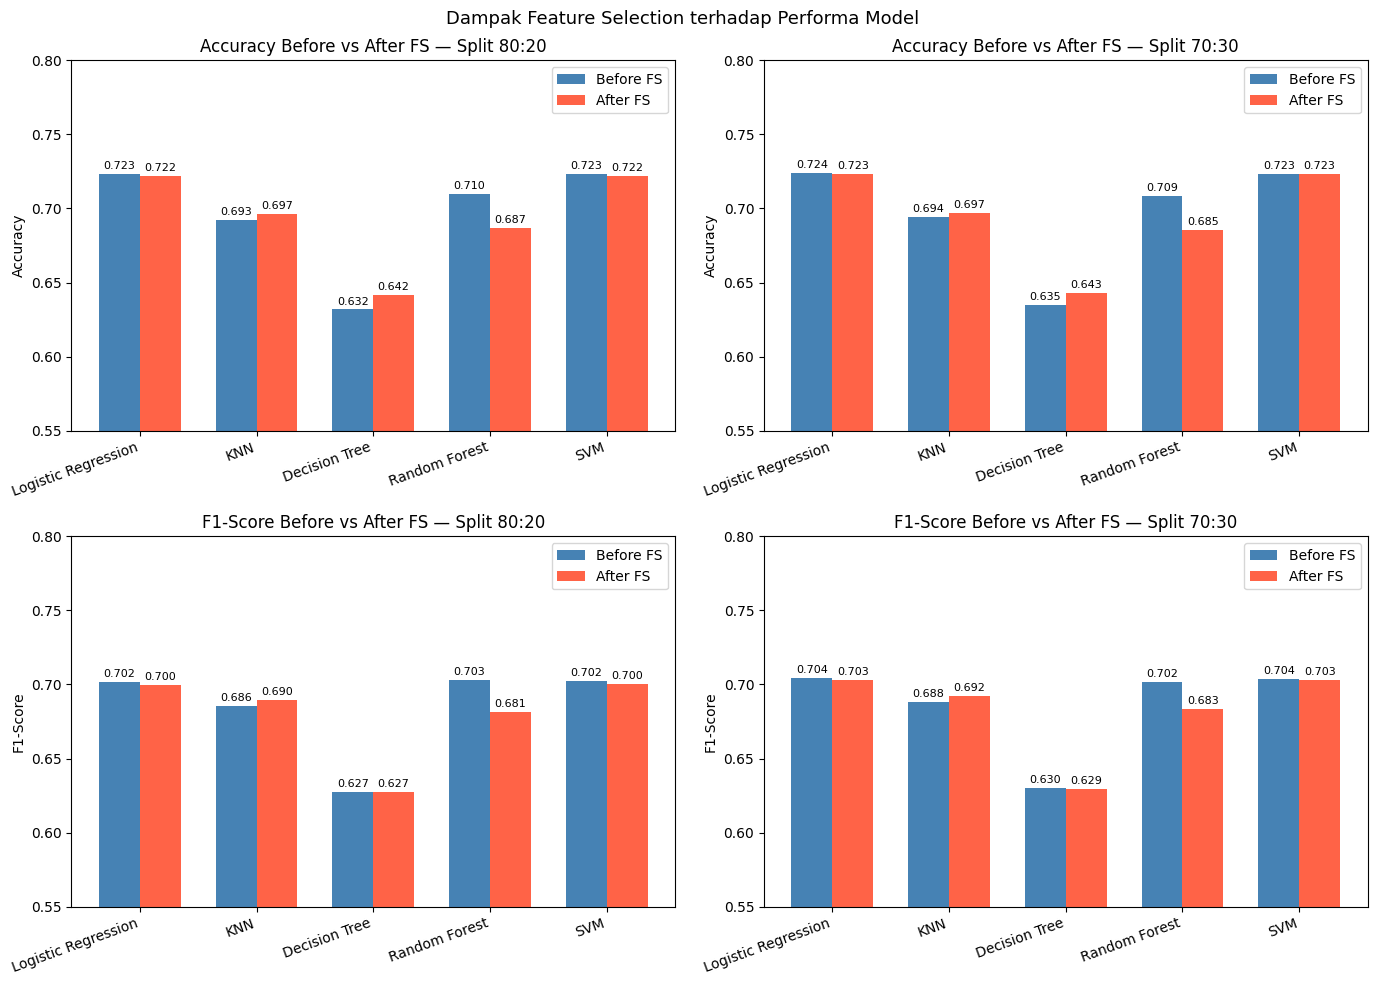

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = [('Accuracy', 'Accuracy'), ('F1-Score', 'F1-Score')]

for row, (metric, metric_label) in enumerate(metrics_to_plot):
    for col, split_name in enumerate(splits.keys()):
        ax    = axes[row, col]
        df_b  = results_before[split_name]
        df_a  = results_after[split_name]
        x     = np.arange(len(df_b))
        width = 0.35

        bars1 = ax.bar(x - width/2, df_b[metric], width, label='Before FS', color='steelblue')
        bars2 = ax.bar(x + width/2, df_a[metric], width, label='After FS',  color='tomato')

        ax.set_xticks(x)
        ax.set_xticklabels(df_b['Model'], rotation=20, ha='right')
        ax.set_title(f'{metric_label} Before vs After FS — Split {split_name}')
        ax.set_ylabel(metric_label)
        ax.set_ylim(0.55, 0.80)
        ax.legend()

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Dampak Feature Selection terhadap Performa Model', fontsize=13)
plt.tight_layout()
plt.savefig('cardio_before_after_fs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Hyperparameter Tuning

Model terbaik dipilih berdasarkan F1-Score dan konsistensi CV Mean di kedua split.
Tuning dilakukan menggunakan **GridSearchCV** dengan CV=5 dan metrik optimasi **F1-score**.

Untuk menghindari bias pemilihan parameter akibat satu split tertentu, tuning dijalankan
secara terpisah untuk masing-masing split (80:20 dan 70:30).

In [16]:
param_grid_lr = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

param_grid_svm = {
    'estimator__C'   : [0.01, 0.1, 1, 10, 100],
    'estimator__loss': ['hinge', 'squared_hinge']
}

lr_tuned_per_split  = {}
svm_tuned_per_split = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    print(f"Tuning Logistic Regression | Split {split_name}...")
    lr_gs = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=0
    )
    lr_gs.fit(X_tr, y_tr)
    lr_tuned_per_split[split_name] = lr_gs
    print(f"  Best params : {lr_gs.best_params_}")
    print(f"  Best CV F1  : {lr_gs.best_score_:.4f}")

    print(f"Tuning SVM | Split {split_name}...")
    svm_gs = GridSearchCV(
        CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)),
        param_grid_svm, cv=5, scoring='f1', n_jobs=-1, verbose=0
    )
    svm_gs.fit(X_tr, y_tr)
    svm_tuned_per_split[split_name] = svm_gs
    print(f"  Best params : {svm_gs.best_params_}")
    print(f"  Best CV F1  : {svm_gs.best_score_:.4f}")
    print()

Tuning Logistic Regression | Split 80:20...
  Best params : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1  : 0.7082
Tuning SVM | Split 80:20...
  Best params : {'estimator__C': 0.1, 'estimator__loss': 'squared_hinge'}
  Best CV F1  : 0.7083

Tuning Logistic Regression | Split 70:30...
  Best params : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV F1  : 0.7092
Tuning SVM | Split 70:30...
  Best params : {'estimator__C': 0.1, 'estimator__loss': 'squared_hinge'}
  Best CV F1  : 0.7089



### 7.1 Perbandingan Sebelum vs Sesudah Tuning (Kedua Split)

In [17]:
print("=" * 65)
print("PERBANDINGAN SEBELUM VS SESUDAH TUNING")
print("=" * 65)

tuning_results = {}

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    tuned_models = {
        'Logistic Regression': (
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            lr_tuned_per_split[split_name].best_estimator_
        ),
        'SVM': (
            CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)),
            svm_tuned_per_split[split_name].best_estimator_
        )
    }

    rows = []
    for model_name, (model_before, model_after) in tuned_models.items():
        for stage, model in [('Before', model_before), ('After', model_after)]:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            rows.append({
                'Model'    : model_name,
                'Stage'    : stage,
                'Accuracy' : round(accuracy_score(y_te, y_pred),  4),
                'Precision': round(precision_score(y_te, y_pred), 4),
                'Recall'   : round(recall_score(y_te, y_pred),    4),
                'F1-Score' : round(f1_score(y_te, y_pred),        4),
            })

    tuning_results[split_name] = pd.DataFrame(rows)

    print(f"\nSplit {split_name}:")
    print(f"{'Model':<22} {'Stage':<8} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    print("-" * 58)
    for _, row in tuning_results[split_name].iterrows():
        print(f"{row['Model']:<22} {row['Stage']:<8} {row['Accuracy']:>7.4f} {row['Precision']:>7.4f} {row['Recall']:>7.4f} {row['F1-Score']:>7.4f}")
    print()

PERBANDINGAN SEBELUM VS SESUDAH TUNING

Split 80:20:
Model                  Stage        Acc    Prec     Rec      F1
----------------------------------------------------------
Logistic Regression    Before    0.7220  0.7511  0.6553  0.6999
Logistic Regression    After     0.7220  0.7509  0.6553  0.6999
SVM                    Before    0.7220  0.7504  0.6562  0.7002
SVM                    After     0.7220  0.7504  0.6562  0.7002


Split 70:30:
Model                  Stage        Acc    Prec     Rec      F1
----------------------------------------------------------
Logistic Regression    Before    0.7234  0.7499  0.6616  0.7030
Logistic Regression    After     0.7233  0.7498  0.6615  0.7029
SVM                    Before    0.7230  0.7486  0.6628  0.7031
SVM                    After     0.7230  0.7486  0.6628  0.7031



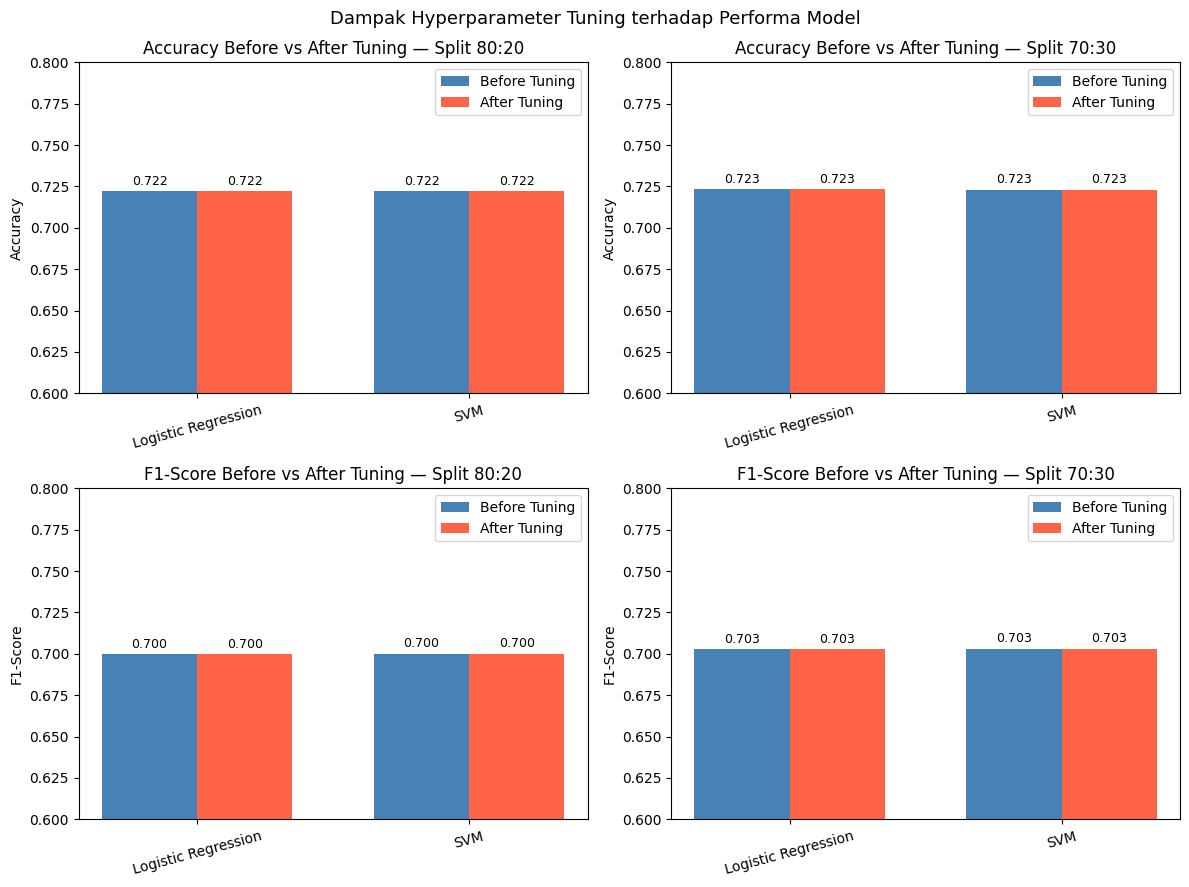

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
metrics_to_plot = [('Accuracy', 'Accuracy'), ('F1-Score', 'F1-Score')]

for row, (metric, metric_label) in enumerate(metrics_to_plot):
    for col, split_name in enumerate(splits.keys()):
        ax          = axes[row, col]
        df_         = tuning_results[split_name]
        model_names = df_['Model'].unique()
        x           = np.arange(len(model_names))
        width       = 0.35

        before_vals = df_[df_['Stage'] == 'Before'][metric].values
        after_vals  = df_[df_['Stage'] == 'After'][metric].values

        bars1 = ax.bar(x - width/2, before_vals, width, label='Before Tuning', color='steelblue')
        bars2 = ax.bar(x + width/2, after_vals,  width, label='After Tuning',  color='tomato')

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15)
        ax.set_title(f'{metric_label} Before vs After Tuning — Split {split_name}')
        ax.set_ylabel(metric_label)
        ax.set_ylim(0.60, 0.80)
        ax.legend()

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Dampak Hyperparameter Tuning terhadap Performa Model', fontsize=13)
plt.tight_layout()
plt.savefig('cardio_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Confusion Matrix & Classification Report

Visualisasi confusion matrix untuk model terbaik (Logistic Regression Tuned) pada kedua split.
Confusion matrix ditampilkan dalam dua bentuk: jumlah absolut dan proporsi ternormalisasi.

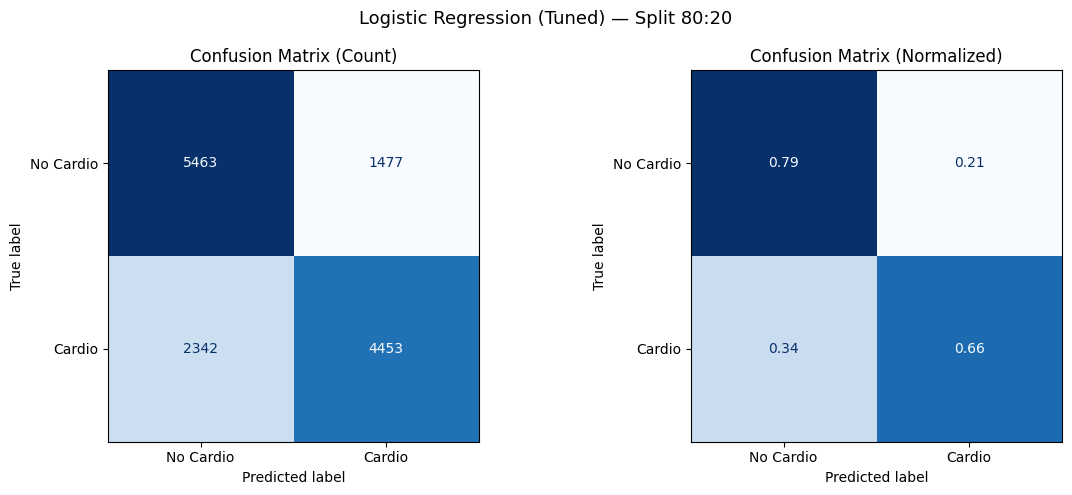

Classification Report — Logistic Regression (Tuned) | Split 80:20:
              precision    recall  f1-score   support

   No Cardio       0.70      0.79      0.74      6940
      Cardio       0.75      0.66      0.70      6795

    accuracy                           0.72     13735
   macro avg       0.73      0.72      0.72     13735
weighted avg       0.73      0.72      0.72     13735




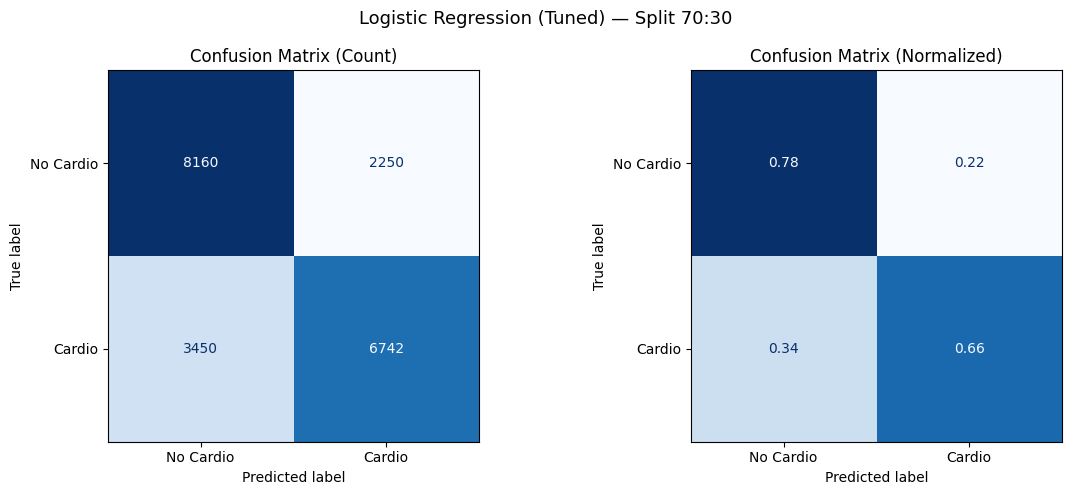

Classification Report — Logistic Regression (Tuned) | Split 70:30:
              precision    recall  f1-score   support

   No Cardio       0.70      0.78      0.74     10410
      Cardio       0.75      0.66      0.70     10192

    accuracy                           0.72     20602
   macro avg       0.73      0.72      0.72     20602
weighted avg       0.73      0.72      0.72     20602




In [19]:
best_model_name = 'Logistic Regression'

for split_name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    best_model = lr_tuned_per_split[split_name].best_estimator_
    best_model.fit(X_tr, y_tr)
    y_pred = best_model.predict(X_te)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, normalize in zip(axes, [None, 'true']):
        cm   = confusion_matrix(y_te, y_pred, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No Cardio', 'Cardio'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        title = 'Confusion Matrix (Count)' if normalize is None else 'Confusion Matrix (Normalized)'
        ax.set_title(title)

    plt.suptitle(f'{best_model_name} (Tuned) — Split {split_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'cardio_confusion_matrix_{split_name.replace(":", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Classification Report — {best_model_name} (Tuned) | Split {split_name}:")
    print(classification_report(y_te, y_pred, target_names=['No Cardio', 'Cardio']))
    print()

---
## 9. Summary Model Terbaik

In [20]:
print("=" * 60)
print("SUMMARY MODEL TERBAIK — LOGISTIC REGRESSION (TUNED)")
print("=" * 60)

for split_name in splits.keys():
    gs        = lr_tuned_per_split[split_name]
    df_       = tuning_results[split_name]
    lr_after  = df_[(df_['Model'] == 'Logistic Regression') & (df_['Stage'] == 'After')].iloc[0]

    print(f"Split {split_name}:")
    print(f"  Best params  : {gs.best_params_}")
    print(f"  Best CV F1   : {gs.best_score_:.4f}")
    print(f"  Accuracy     : {lr_after['Accuracy']:.4f}")
    print(f"  Precision    : {lr_after['Precision']:.4f}")
    print(f"  Recall       : {lr_after['Recall']:.4f}")
    print(f"  F1-Score     : {lr_after['F1-Score']:.4f}")
    print()

SUMMARY MODEL TERBAIK — LOGISTIC REGRESSION (TUNED)
Split 80:20:
  Best params  : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1   : 0.7082
  Accuracy     : 0.7220
  Precision    : 0.7509
  Recall       : 0.6553
  F1-Score     : 0.6999

Split 70:30:
  Best params  : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV F1   : 0.7092
  Accuracy     : 0.7233
  Precision    : 0.7498
  Recall       : 0.6615
  F1-Score     : 0.7029

